# Training a Markov GP — hyperparameter learning

`MarkovGPPrior.log_marginal(y, noise_var)` is the Kalman-filter marginal likelihood. It is differentiable in every kernel hyperparameter (`variance`, `lengthscale`, `noise_var`, ...) thanks to JAX's automatic differentiation through the SDE construction and the `lax.scan`-based filter. That makes hyperparameter learning a one-line gradient descent.

This notebook

1. generates a noisy 1-D time series,
2. defines a `MaternSDE` prior and treats `(log_variance, log_lengthscale, log_noise_var)` as free parameters,
3. minimises the negative log marginal likelihood via L-BFGS,
4. visualises the learned predictive against the data.

In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from pyrox.gp import MarkovGPPrior, MaternSDE


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic data

A noisy mixture of two sinusoids on an irregular time grid. Wide enough lengthscale that a Matern-3/2 SDE prior fits cleanly.

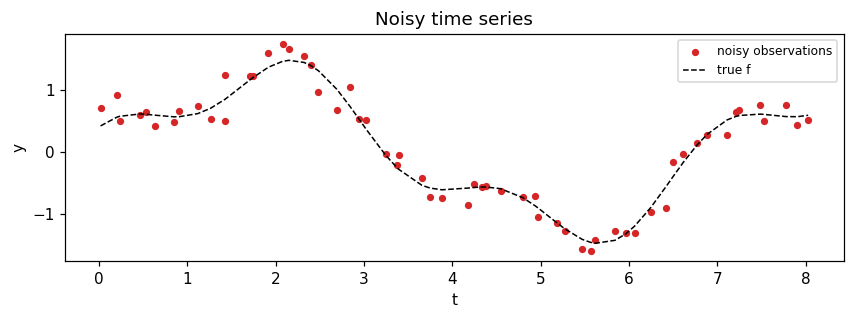

In [2]:
N = 60
t_clean = jnp.linspace(0.0, 8.0, N)
times = jnp.sort(t_clean + 0.05 * jax.random.normal(jax.random.PRNGKey(2), (N,)))
f_true = 1.2 * jnp.sin(0.9 * times) + 0.4 * jnp.cos(2.7 * times)
y = f_true + 0.18 * jax.random.normal(key, (N,))

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(times, y, c="C3", s=14, label="noisy observations")
ax.plot(times, f_true, "k--", lw=1, label="true f")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.set_title("Noisy time series")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Parameterise the hyperparameters

We optimise in *log-space* so the constraint $\sigma^2, \ell, \sigma_n^2 > 0$ is automatically satisfied. The model lives in a tiny `equinox.Module` so it composes cleanly with `optax`.

In [3]:
class MarkovGPModel(eqx.Module):
    log_variance: jax.Array
    log_lengthscale: jax.Array
    log_noise_var: jax.Array
    times: jax.Array

    def __init__(self, times: jax.Array, init: tuple[float, float, float]) -> None:
        self.log_variance = jnp.asarray(jnp.log(init[0]))
        self.log_lengthscale = jnp.asarray(jnp.log(init[1]))
        self.log_noise_var = jnp.asarray(jnp.log(init[2]))
        self.times = times

    def neg_log_marginal(self, y: jax.Array) -> jax.Array:
        sde = MaternSDE(
            variance=jnp.exp(self.log_variance),
            lengthscale=jnp.exp(self.log_lengthscale),
            order=1,
        )
        prior = MarkovGPPrior(sde, self.times)
        return -prior.log_marginal(y, jnp.exp(self.log_noise_var))


model = MarkovGPModel(times, init=(0.5, 0.5, 0.1))
print(f"initial NLL: {float(model.neg_log_marginal(y)):.3f}")

initial NLL: 25.522


## Optimise with L-BFGS

In [4]:
@eqx.filter_jit
def loss_and_grad(m: MarkovGPModel, y: jax.Array) -> tuple[jax.Array, MarkovGPModel]:
    return eqx.filter_value_and_grad(lambda mm: mm.neg_log_marginal(y))(m)


opt = optax.lbfgs()
params, static = eqx.partition(model, eqx.is_array)
opt_state = opt.init(params)


@eqx.filter_jit
def step(params, static, opt_state, y):
    m = eqx.combine(params, static)
    val, grads = loss_and_grad(m, y)
    grad_params, _ = eqx.partition(grads, eqx.is_array)
    updates, opt_state = opt.update(
        grad_params,
        opt_state,
        params,
        value=val,
        grad=grad_params,
        value_fn=lambda p: eqx.combine(p, static).neg_log_marginal(y),
    )
    params = optax.apply_updates(params, updates)
    return params, opt_state, val


losses = []
hyper_traces = {"variance": [], "lengthscale": [], "noise_var": []}
for it in range(40):
    params, opt_state, val = step(params, static, opt_state, y)
    losses.append(float(val))
    m_now = eqx.combine(params, static)
    hyper_traces["variance"].append(float(jnp.exp(m_now.log_variance)))
    hyper_traces["lengthscale"].append(float(jnp.exp(m_now.log_lengthscale)))
    hyper_traces["noise_var"].append(float(jnp.exp(m_now.log_noise_var)))

trained = eqx.combine(params, static)
print(f"final NLL: {losses[-1]:.3f}")
print(f"learned variance:    {hyper_traces['variance'][-1]:.3f}")
print(f"learned lengthscale: {hyper_traces['lengthscale'][-1]:.3f}")
print(f"learned noise_var:   {hyper_traces['noise_var'][-1]:.4f}")

final NLL: -16.552
learned variance:    0.410
learned lengthscale: 1.692
learned noise_var:   0.0203


## Convergence diagnostics

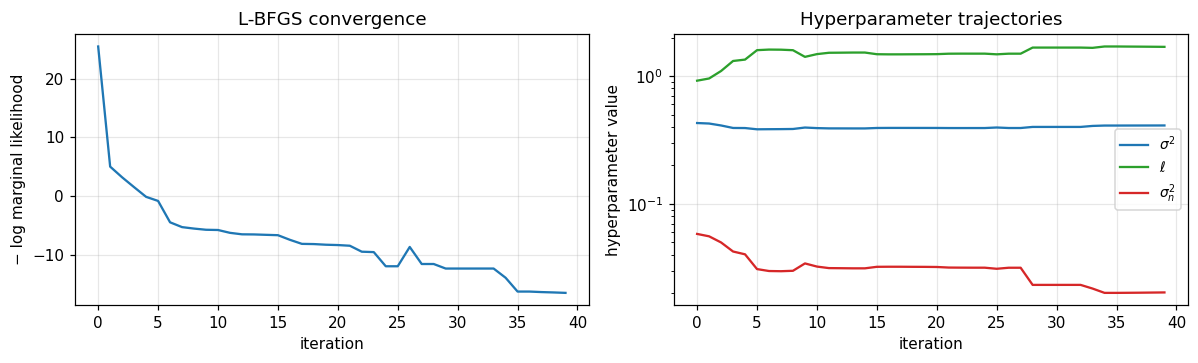

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(losses, "C0", lw=1.5)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("− log marginal likelihood")
axes[0].set_title("L-BFGS convergence")
axes[0].grid(alpha=0.3)

axes[1].plot(hyper_traces["variance"], label=r"$\sigma^2$", color="C0")
axes[1].plot(hyper_traces["lengthscale"], label=r"$\ell$", color="C2")
axes[1].plot(hyper_traces["noise_var"], label=r"$\sigma_n^2$", color="C3")
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("hyperparameter value")
axes[1].set_title("Hyperparameter trajectories")
axes[1].set_yscale("log")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Posterior predictive at the learned hyperparameters

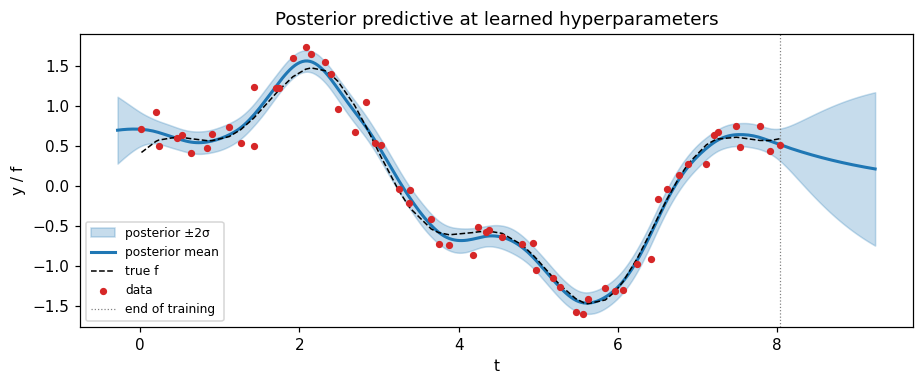

In [6]:
sde_final = MaternSDE(
    variance=jnp.exp(trained.log_variance),
    lengthscale=jnp.exp(trained.log_lengthscale),
    order=1,
)
prior_final = MarkovGPPrior(sde_final, times)
cond = prior_final.condition(y, jnp.exp(trained.log_noise_var))

t_star = jnp.linspace(times[0] - 0.3, times[-1] + 1.2, 300)
m_star, v_star = cond.predict(t_star)
m_star, v_star = np.asarray(m_star), np.asarray(v_star)
sd_star = np.sqrt(np.maximum(v_star, 0))

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.fill_between(
    t_star,
    m_star - 2 * sd_star,
    m_star + 2 * sd_star,
    color="C0",
    alpha=0.25,
    label="posterior ±2σ",
)
ax.plot(t_star, m_star, color="C0", lw=2, label="posterior mean")
ax.plot(times, f_true, "k--", lw=1, label="true f")
ax.scatter(times, y, c="C3", s=14, label="data", zorder=3)
ax.axvline(times[-1], color="grey", ls=":", lw=0.8, label="end of training")
ax.set_xlabel("t")
ax.set_ylabel("y / f")
ax.set_title("Posterior predictive at learned hyperparameters")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## Summary

- `MarkovGPPrior.log_marginal` is end-to-end differentiable; any optimiser (L-BFGS, Adam, ...) trains the kernel hyperparameters.
- Optimising in log-space sidesteps positivity constraints with no manual reparameterisation gymnastics.
- The fitted hyperparameters give a sensible posterior mean and uncertainty band, and the model extrapolates to the prior beyond the training window — the standard stationary-GP behaviour.

For non-Gaussian likelihoods, plug a `MarkovGPPrior` into one of the strategies in the companion *non-Gaussian Markov GP* notebook; the same optimisation workflow applies, just with `strategy.fit(...).log_marginal_approx` as the loss.